# Local Spatial Clustering & Hot-Spot Overlap Analysis (LISA)

**Author:** Gustavo Fuentes (`Audileleach`) · Phase 3 · TEAM_PLAN §4.6
**Study Area:** Mexico City city-core urban AGEBs (2,348 units; 2,297 for the crime rate)
**Methodology:** Local Indicators of Spatial Association (LISA, Anselin 1995) with Nora's shared helpers in `src.analysis.spatial_weights`

This notebook builds on Nora's LISA (`notebooks/32_global_moran_lisa.ipynb`) and does not repeat it. It answers four questions:
1. **Where are the clusters?** Count and share of HH / LL / HL / LH AGEBs per alcaldía for business density and crime rate.
2. **Do business-density hot spots coincide with crime-rate hot spots?** Cross-tab of the two cluster labels and the list of overlapping AGEBs.
3. **How robust are the labels to the neighbourhood rule?** Queen contiguity vs KNN-6.
4. **How many labels survive a multiple-testing correction?** Pseudo p-values are computed for thousands of AGEBs at once.

> **Caution on interpretation:** cluster labels describe exploratory spatial association, not causal effects or individual victimisation risk. The crime rate uses resident population as denominator, so AGEBs with many visitors and few residents (commercial and historic centre) show high rates.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
from esda import fdr

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis.data import load_kpis
from src.analysis.spatial_weights import build_weights, local_clusters
from src.config import OUTPUT_MAPS
from src.db import get_engine

OUTPUT_MAPS.mkdir(parents=True, exist_ok=True)

LISA_COLORS = {'HH': '#b2182b', 'LL': '#2166ac', 'HL': '#ef8a62', 'LH': '#67a9cf', 'ns': '#e0e0e0'}
CLUSTERS = ['HH', 'LL', 'HL', 'LH']
SEED = 42
PERMUTATIONS = 999
ALPHA = 0.05

## 1. Load Warehouse KPIs & Build Spatial Weights

Data come from `dw.v_kpi_ageb` through `load_kpis()`; alcaldía names come from `dw.dim_geography`. Samples and weights are the same as in Nora's notebook 32:
- **Business density** uses all 2,348 city-core AGEBs (`cve_loc = '0001'`).
- **Crime rate** uses the 2,297 city-core AGEBs with at least 100 residents (51 low-population AGEBs dropped, TEAM_PLAN §3.1).
- Weights are built on each indicator's own sample: row-standardised Queen contiguity (island attached to its nearest neighbour) and KNN $k=6$ as sensitivity check.

In [2]:
mun_names = pd.read_sql("SELECT cvegeo, mun_name FROM dw.dim_geography", get_engine()).set_index('cvegeo')['mun_name']

gdf_core = load_kpis(city_core_only=True, exclude_low_population=False).set_index('cvegeo')
gdf_core['mun_name'] = mun_names.reindex(gdf_core.index)
assert len(gdf_core) == 2348, f"Expected 2,348 city-core AGEBs, got {len(gdf_core)}"
assert gdf_core['mun_name'].notna().all() and gdf_core['mun_name'].nunique() == 16

# Rate sample: exclude low population (pop_total < 100)
gdf_rate = gdf_core[~gdf_core['low_population']].copy()
assert len(gdf_rate) == 2297, f"Expected 2,297 non-low-population AGEBs, got {len(gdf_rate)}"

w_queen_core = build_weights(gdf_core, kind="queen")
w_knn_core = build_weights(gdf_core, kind="knn", k=6)
w_queen_rate = build_weights(gdf_rate, kind="queen")
w_knn_rate = build_weights(gdf_rate, kind="knn", k=6)

print(f"Loaded {len(gdf_core)} city-core AGEBs and {len(gdf_rate)} AGEBs with >= 100 residents.")

Loaded 2348 city-core AGEBs and 2297 AGEBs with >= 100 residents.


## 2. Compute Local Moran Clusters (LISA)

Nora's `local_clusters()` with 999 permutations, `seed=42` and α = 0.05.

In [3]:
lisa_biz_q = local_clusters(gdf_core, 'business_density_km2', w_queen_core, permutations=PERMUTATIONS, alpha=ALPHA, seed=SEED)
lisa_biz_k = local_clusters(gdf_core, 'business_density_km2', w_knn_core, permutations=PERMUTATIONS, alpha=ALPHA, seed=SEED)
lisa_crime_q = local_clusters(gdf_rate, 'crime_rate_per_1k', w_queen_rate, permutations=PERMUTATIONS, alpha=ALPHA, seed=SEED)
lisa_crime_k = local_clusters(gdf_rate, 'crime_rate_per_1k', w_knn_rate, permutations=PERMUTATIONS, alpha=ALPHA, seed=SEED)

summary = pd.DataFrame({
    'Business density (Queen)': lisa_biz_q['cluster'].value_counts(),
    'Business density (KNN-6)': lisa_biz_k['cluster'].value_counts(),
    'Crime rate (Queen)': lisa_crime_q['cluster'].value_counts(),
    'Crime rate (KNN-6)': lisa_crime_k['cluster'].value_counts(),
}).reindex(CLUSTERS + ['ns']).fillna(0).astype(int)
summary.loc['Total'] = summary.sum()
display(summary)

,Business density (Queen),Business density (KNN-6),Crime rate (Queen),Crime rate (KNN-6)
cluster,,,,
HH,109,121,110,72
LL,312,289,344,451
HL,33,28,10,13
LH,28,36,76,29
ns,1866,1874,1757,1732
Total,2348,2348,2297,2297


## 3. Where Are the Clusters? Counts and Shares per Alcaldía

For each alcaldía: number of AGEBs in the indicator's sample (`n`), number of AGEBs in each cluster type (Queen weights) and their share of the alcaldía's AGEBs (%). The last column of each block is the alcaldía's share of all the city's HH AGEBs for that indicator.

In [4]:
def clusters_by_alcaldia(lisa: pd.DataFrame) -> pd.DataFrame:
    counts = pd.crosstab(gdf_core.loc[lisa.index, 'mun_name'], lisa['cluster']).reindex(columns=CLUSTERS + ['ns'], fill_value=0)
    table = pd.DataFrame({'n': counts.sum(axis=1)})
    for cluster in CLUSTERS:
        table[cluster] = counts[cluster]
        table[f'{cluster} %'] = (100 * counts[cluster] / table['n']).round(1)
    table['share of city HH %'] = (100 * counts['HH'] / counts['HH'].sum()).round(1)
    return table

by_alcaldia = pd.concat({
    'Business density': clusters_by_alcaldia(lisa_biz_q),
    'Crime rate': clusters_by_alcaldia(lisa_crime_q),
}, axis=1).sort_values(('Business density', 'HH'), ascending=False)
display(by_alcaldia)

table_path = OUTPUT_MAPS / "34_clusters_by_alcaldia.csv"
by_alcaldia.to_csv(table_path)
print(f"Saved cluster counts per alcaldía to {table_path.relative_to(ROOT)}")

Business density                                      \
                                      n  HH  HH %  LL  LL % HL HL % LH LH %   
mun_name                                                                      
Cuauhtémoc                          153  76  49.7   0   0.0  0  0.0  8  5.2   
Venustiano Carranza                 151  12   7.9   1   0.7  0  0.0  9  6.0   
Miguel Hidalgo                      130   7   5.4  16  12.3  2  1.5  5  3.8   
Benito Juárez                       102   4   3.9   0   0.0  0  0.0  1  1.0   
Iztapalapa                          458   4   0.9  13   2.8  3  0.7  0  0.0   
Xochimilco                          122   4   3.3  74  60.7  1  0.8  2  1.6   
Iztacalco                           110   2   1.8   0   0.0  0  0.0  3  2.7   
Cuajimalpa de Morelos                28   0   0.0  10  35.7  1  3.6  0  0.0   
Gustavo A. Madero                   305   0   0.0  24   7.9  7  2.3  0  0.0   
Azcapotzalco                        103   0   0.0  13  12.6  2  1.9  0  0.0   
Coyoacán                            156   0   0.0  27  17.3  5  3.2  0  0.0   
La Magdalena Contreras               52   0   0.0   9  17.3  1  1.9  0  0.0   
Tlalpan                             180   0   0.0  67  37.2  5  2.8  0  0.0   
Milpa Alta                            8   0   0.0   2  25.0  0  0.0  0  0.0   
Tláhuac                              91   0   0.0   8   8.8  2  2.2  0  0.0   
Álvaro Obregón                      199   0   0.0  48  24.1  4  2.0  0  0.0   

                                          Crime rate                          \
                       share of city HH %          n  HH  HH %   LL  LL % HL   
mun_name                                                                       
Cuauhtémoc                           69.7        152  47  30.9    0   0.0  0   
Venustiano Carranza                  11.0        145   8   5.5    7   4.8  0   
Miguel Hidalgo                        6.4        114  14  12.3    2   1.8  0   
Benito Juárez                         3.7        102  10   9.8    0   0.0  0   
Iztapalapa                            3.7        453   2   0.4  164  36.2  1   
Xochimilco                            3.7        118   0   0.0   28  23.7  1   
Iztacalco                             1.8        107   0   0.0    0   0.0  0   
Cuajimalpa de Morelos                 0.0         28   0   0.0    6  21.4  0   
Gustavo A. Madero                     0.0        300   9   3.0   61  20.3  2   
Azcapotzalco                          0.0        102   2   2.0    1   1.0  1   
Coyoacán                              0.0        155   7   4.5    2   1.3  0   
La Magdalena Contreras                0.0         52   0   0.0    2   3.8  0   
Tlalpan                               0.0        175   5   2.9   14   8.0  0   
Milpa Alta                            0.0          8   0   0.0    0   0.0  0   
Tláhuac                               0.0         90   0   0.0    6   6.7  1   
Álvaro Obregón                        0.0        196   6   3.1   51  26.0  4   

                                                          
                       HL %  LH  LH % share of city HH %  
mun_name                                                  
Cuauhtémoc              0.0  16  10.5               42.7  
Venustiano Carranza     0.0   9   6.2                7.3  
Miguel Hidalgo          0.0   5   4.4               12.7  
Benito Juárez           0.0   5   4.9                9.1  
Iztapalapa              0.2   8   1.8                1.8  
Xochimilco              0.8   0   0.0                0.0  
Iztacalco               0.0   2   1.9                0.0  
Cuajimalpa de Morelos   0.0   0   0.0                0.0  
Gustavo A. Madero       0.7  13   4.3                8.2  
Azcapotzalco            1.0   1   1.0                1.8  
Coyoacán                0.0  12   7.7                6.4  
La Magdalena Contreras  0.0   0   0.0                0.0  
Tlalpan                 0.0   2   1.1                4.5  
Milpa Alta              0.0   0   0.0                0.0

Saved cluster counts per alcaldía to outputs\maps\34_clusters_by_alcaldia.csv


## 4. Do Business Hot Spots Coincide with Crime Hot Spots?

Both labels are compared on the common sample of **2,297 AGEBs** (the business label of each AGEB is the one computed on the 2,348-AGEB sample, as in notebook 32).

In [5]:
overlap = pd.DataFrame({
    'cvegeo': gdf_rate.index,
    'mun_name': gdf_rate['mun_name'],
    'pop_total': gdf_rate['pop_total'],
    'businesses_total': gdf_rate['businesses_total'],
    'crime_total': gdf_rate['crime_total'],
    'business_density_km2': gdf_rate['business_density_km2'].round(1),
    'crime_rate_per_1k': gdf_rate['crime_rate_per_1k'].round(2),
    'dominant_sector': gdf_rate['dominant_sector'],
    'biz_cluster': lisa_biz_q.loc[gdf_rate.index, 'cluster'],
    'biz_p_sim': lisa_biz_q.loc[gdf_rate.index, 'p_sim'],
    'crime_cluster': lisa_crime_q['cluster'],
    'crime_p_sim': lisa_crime_q['p_sim'],
    'biz_cluster_knn': lisa_biz_k.loc[gdf_rate.index, 'cluster'],
    'crime_cluster_knn': lisa_crime_k['cluster'],
}).set_index('cvegeo')

crosstab = pd.crosstab(
    overlap['biz_cluster'], overlap['crime_cluster'],
    rownames=['Business density (LISA)'], colnames=['Crime rate (LISA)'], margins=True,
)
display(crosstab)

hh_overlap = overlap[overlap['biz_cluster'].eq('HH') & overlap['crime_cluster'].eq('HH')].copy()
biz_hh = overlap['biz_cluster'].eq('HH').sum()
crime_hh = overlap['crime_cluster'].eq('HH').sum()
print(f"AGEBs that are HH for both indicators: {len(hh_overlap)} "
      f"({len(hh_overlap) / biz_hh:.0%} of the {biz_hh} business HH, {len(hh_overlap) / crime_hh:.0%} of the {crime_hh} crime HH)")
display(hh_overlap['mun_name'].value_counts().to_frame(name='AGEBs HH for both'))

export_path = OUTPUT_MAPS / "34_hotspot_overlap_agebs.csv"
hh_overlap.sort_values(['mun_name', 'cvegeo']).to_csv(export_path)
print(f"Saved the overlapping AGEBs to {export_path.relative_to(ROOT)}")

Crime rate (LISA),HH,HL,LH,LL,ns,All
Business density (LISA),,,,,,
HH,35,0,5,2,67,109
HL,0,0,0,7,24,31
LH,3,0,2,0,21,26
LL,10,2,9,65,215,301
ns,62,8,60,270,1430,1830
All,110,10,76,344,1757,2297


AGEBs that are HH for both indicators: 35 (32% of the 109 business HH, 32% of the 110 crime HH)


,AGEBs HH for both
mun_name,
Cuauhtémoc,31
Miguel Hidalgo,2
Venustiano Carranza,2


Saved the overlapping AGEBs to outputs\maps\34_hotspot_overlap_agebs.csv


## 5. Cluster Maps with Alcaldía Boundaries

Left and centre: the Queen LISA clusters of each indicator on its own sample. Right: where the two sets of hot spots overlap. Alcaldía outlines are dissolved from the city-core AGEBs (the warehouse stores AGEBs, not alcaldía polygons).

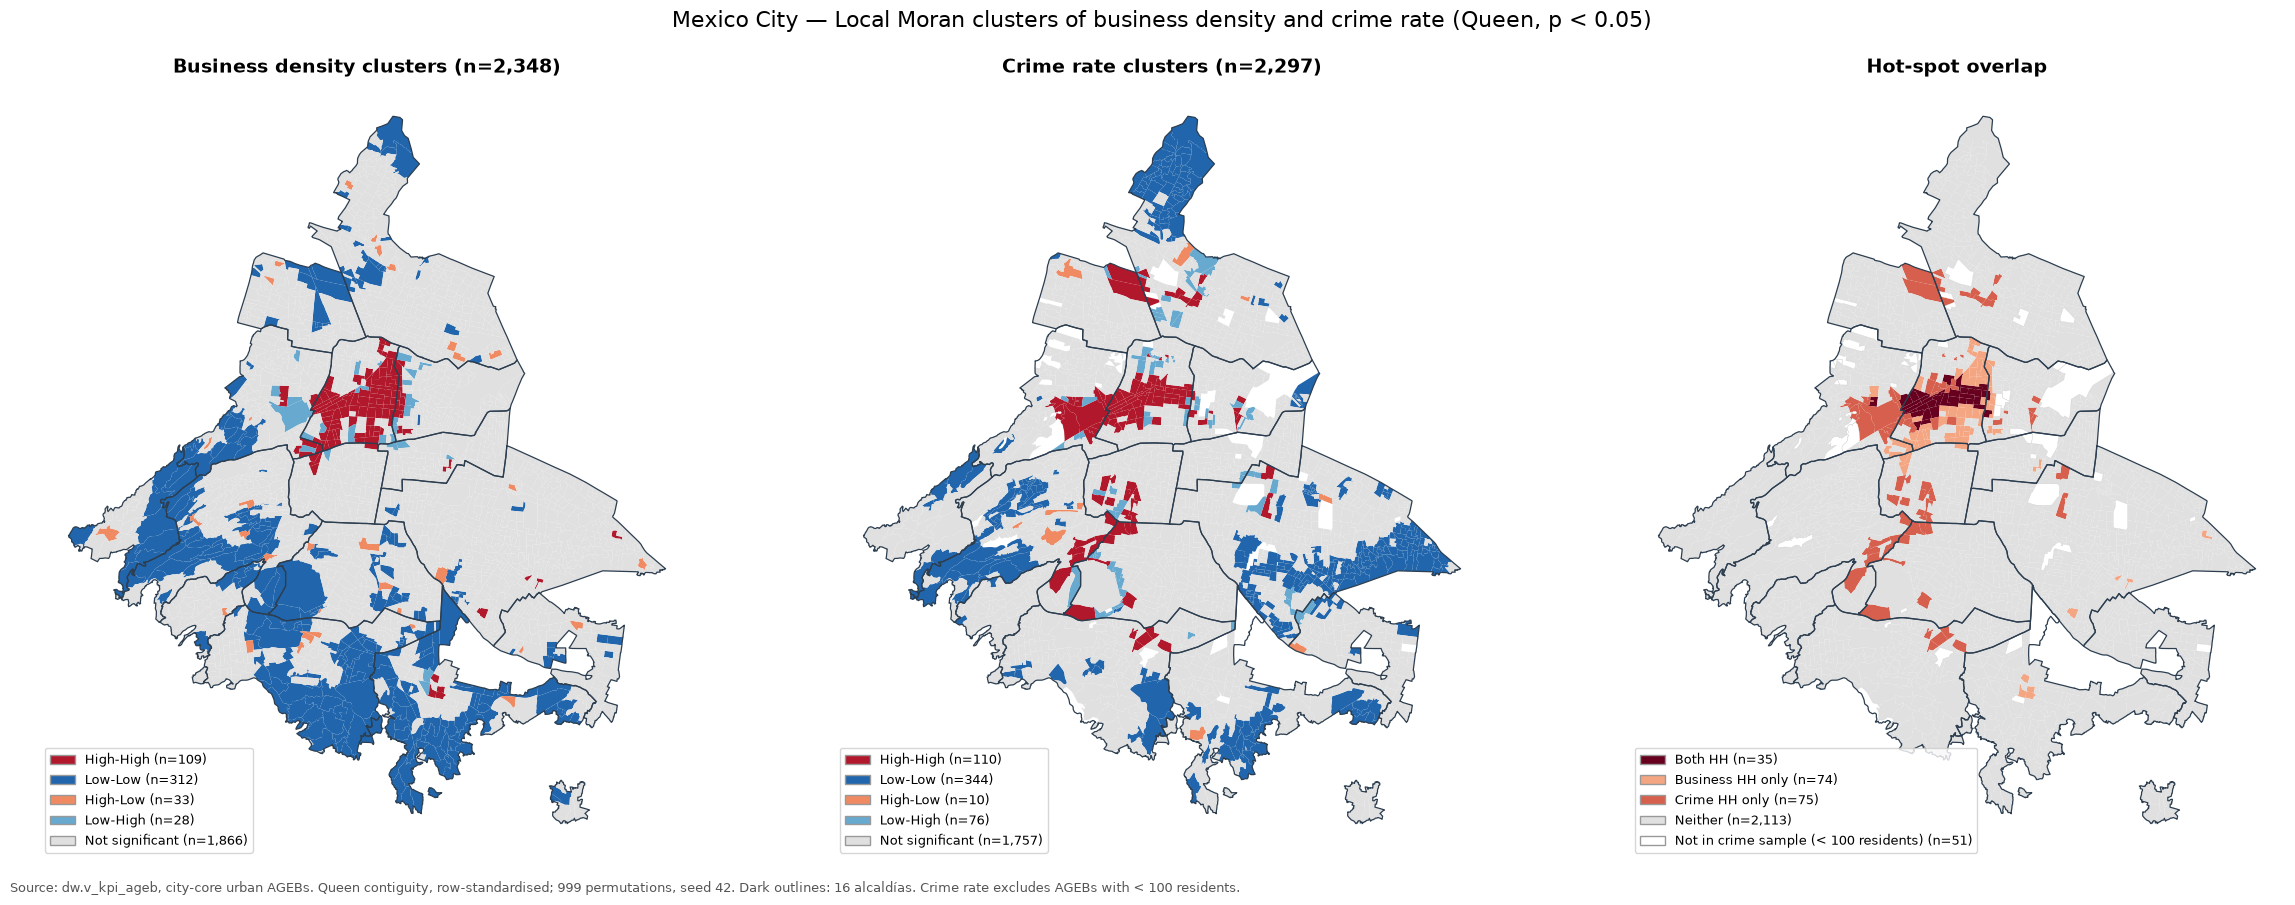

Saved cluster map to outputs\maps\34_hotspot_clusters_alcaldia.png


In [6]:
alcaldias = gdf_core[['mun_name', 'geom']].dissolve(by='mun_name')

def overlap_type(row) -> str:
    if row['biz_cluster'] == 'HH' and row['crime_cluster'] == 'HH':
        return 'Both HH'
    if row['biz_cluster'] == 'HH':
        return 'Business HH only'
    if row['crime_cluster'] == 'HH':
        return 'Crime HH only'
    return 'Neither'

overlap_map = gdf_core[['geom']].join(overlap[['biz_cluster', 'crime_cluster']])
overlap_map['type'] = overlap_map.apply(overlap_type, axis=1)
overlap_map.loc[overlap_map['crime_cluster'].isna(), 'type'] = 'Not in crime sample (< 100 residents)'
OVERLAP_COLORS = {
    'Both HH': '#67001f', 'Business HH only': '#f4a582', 'Crime HH only': '#d6604d',
    'Neither': '#e0e0e0', 'Not in crime sample (< 100 residents)': '#ffffff',
}

fig, axes = plt.subplots(1, 3, figsize=(24, 9))
panels = [
    (gdf_core.join(lisa_biz_q), 'cluster', LISA_COLORS, f'Business density clusters (n={len(gdf_core):,})'),
    (gdf_rate.join(lisa_crime_q), 'cluster', LISA_COLORS, f'Crime rate clusters (n={len(gdf_rate):,})'),
    (overlap_map, 'type', OVERLAP_COLORS, 'Hot-spot overlap'),
]
cluster_names = {'HH': 'High-High', 'LL': 'Low-Low', 'HL': 'High-Low', 'LH': 'Low-High', 'ns': 'Not significant'}
for ax, (frame, col, colors, title) in zip(axes, panels):
    for category, color in colors.items():
        subset = frame[frame[col] == category]
        if not subset.empty:
            subset.plot(ax=ax, color=color, edgecolor='#bdbdbd' if color == '#ffffff' else 'none', linewidth=0.2)
    alcaldias.boundary.plot(ax=ax, color='#2c3e50', linewidth=0.9)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off()
    handles = [
        Patch(facecolor=color, edgecolor='#999', label=f"{cluster_names.get(category, category)} (n={frame[col].eq(category).sum():,})")
        for category, color in colors.items()
    ]
    ax.legend(handles=handles, loc='lower left', frameon=True, fontsize=9)

fig.suptitle("Mexico City — Local Moran clusters of business density and crime rate (Queen, p < 0.05)", fontsize=16, y=0.99)
fig.text(0.02, 0.01, "Source: dw.v_kpi_ageb, city-core urban AGEBs. Queen contiguity, row-standardised; 999 permutations, seed 42. "
         "Dark outlines: 16 alcaldías. Crime rate excludes AGEBs with < 100 residents.", fontsize=9, color='#555')
plt.tight_layout(rect=(0, 0.03, 1, 0.97))

map_path = OUTPUT_MAPS / "34_hotspot_clusters_alcaldia.png"
fig.savefig(map_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved cluster map to {map_path.relative_to(ROOT)}")

## 6. Robustness: Queen vs KNN-6

Each indicator is compared on its own sample. Because most AGEBs are not significant under both rules, overall agreement is dominated by `ns`; the agreement among AGEBs that are significant with Queen and the share of Queen HH that remain HH with KNN-6 are the stricter measures.

In [7]:
rows = []
for label, queen, knn in [
    ('Business density', lisa_biz_q, lisa_biz_k),
    ('Crime rate', lisa_crime_q, lisa_crime_k),
]:
    same = queen['cluster'].eq(knn['cluster'])
    significant = queen['cluster'].ne('ns')
    hh = queen['cluster'].eq('HH')
    rows.append({
        'Indicator': label,
        'n': len(queen),
        'Same label, all AGEBs (%)': round(100 * same.mean(), 1),
        'Significant with Queen': int(significant.sum()),
        'Same label, Queen-significant (%)': round(100 * same[significant].mean(), 1),
        'HH Queen': int(hh.sum()),
        'HH KNN-6': int(knn['cluster'].eq('HH').sum()),
        'Queen HH still HH with KNN-6 (%)': round(100 * knn.loc[hh, 'cluster'].eq('HH').mean(), 1),
    })
robustness = pd.DataFrame(rows).set_index('Indicator')
display(robustness)

both_hh_knn = (overlap['biz_cluster_knn'].eq('HH') & overlap['crime_cluster_knn'].eq('HH'))
both_hh_both_rules = both_hh_knn & overlap.index.isin(hh_overlap.index)
print(f"AGEBs HH for both indicators: {len(hh_overlap)} with Queen, {both_hh_knn.sum()} with KNN-6, "
      f"{both_hh_both_rules.sum()} under both rules.")

,n,"Same label, all AGEBs (%)",Significant with Queen,"Same label, Queen-significant (%)",HH Queen,HH KNN-6,Queen HH still HH with KNN-6 (%)
Indicator,,,,,,,
Business density,2348,89.2,482,72.8,109,121,88.1
Crime rate,2297,87.0,540,74.1,110,72,59.1


AGEBs HH for both indicators: 35 with Queen, 38 with KNN-6, 32 under both rules.


## 7. Multiple Testing

Local Moran's I runs one permutation test per AGEB: 2,348 tests for business density and 2,297 for the crime rate. At α = 0.05, about 5 % of AGEBs (≈ 115–117) would be labelled significant even if values were spatially random, so not every labelled AGEB is a real cluster member; neighbouring tests are also correlated because they share neighbours. The table compares α = 0.05 with α = 0.01 and with the Benjamini–Hochberg false discovery rate (`esda.fdr`, 5 %). With 999 permutations the smallest attainable pseudo p-value is 0.001.

In [8]:
rows = []
for label, lisa in [('Business density', lisa_biz_q), ('Crime rate', lisa_crime_q)]:
    p = lisa['p_sim']
    hh = lisa['cluster'].eq('HH')
    cutoff = fdr(p.to_numpy(), ALPHA)
    rows.append({
        'Indicator': label,
        'n tests': len(p),
        'Expected false positives at 0.05': round(ALPHA * len(p)),
        'Significant p < 0.05': int((p < 0.05).sum()),
        'Significant p < 0.01': int((p < 0.01).sum()),
        'FDR cutoff': cutoff,
        'Significant under FDR': int((p <= cutoff).sum()),
        'HH p < 0.05': int(hh.sum()),
        'HH p < 0.01': int((hh & (p < 0.01)).sum()),
        'HH under FDR': int((hh & (p <= cutoff)).sum()),
    })
multiple_testing = pd.DataFrame(rows).set_index('Indicator')
display(multiple_testing)

strict = (hh_overlap['biz_p_sim'] < 0.01) & (hh_overlap['crime_p_sim'] < 0.01)
print(f"AGEBs HH for both indicators with p < 0.01 in both tests: {strict.sum()} of {len(hh_overlap)}")

,n tests,Expected false positives at 0.05,Significant p < 0.05,Significant p < 0.01,FDR cutoff,Significant under FDR,HH p < 0.05,HH p < 0.01,HH under FDR
Indicator,,,,,,,,,
Business density,2348,117,482,199,0.002364,111,109,45,25
Crime rate,2297,115,540,203,0.001241,57,110,30,12


AGEBs HH for both indicators with p < 0.01 in both tests: 12 of 35


## 8. Interpretation

- **Business-density hot spots sit in the centre.** 76 of the 109 HH AGEBs (70 %) are in Cuauhtémoc, followed by Venustiano Carranza (12) and Miguel Hidalgo (7). Low-low clusters lie in the southern and western alcaldías with lower-density settlement (Xochimilco 74, Tlalpan 67 and Álvaro Obregón 48 LL AGEBs).
- **Crime-rate hot spots are more spread out.** Cuauhtémoc holds 47 of the 110 HH AGEBs (43 %), but Miguel Hidalgo (14), Benito Juárez (10), Gustavo A. Madero (9) and Venustiano Carranza (8) also have them. The largest cold spot is in Iztapalapa: 164 LL AGEBs, 36 % of its AGEBs in the sample.
- **The two sets of hot spots overlap only partly.** 35 AGEBs are HH for both indicators (32 % of each set): 31 in Cuauhtémoc, 2 in Miguel Hidalgo and 2 in Venustiano Carranza. Another 62 crime HH AGEBs are not significant for business density, so high recorded crime per resident also clusters outside the commercial core. The overlap is an association between two indicators measured on the same AGEBs. It does not show that businesses generate crime, and the per-resident crime rate is inflated where residents are few and visitors many.
- **Robustness.** Overall Queen vs KNN-6 agreement (89 % business, 87 % crime) is driven by AGEBs that are not significant under either rule; among Queen-significant AGEBs it falls to 73 % and 74 %. Business HH are stable (88 % stay HH with KNN-6), crime HH much less so (59 %; 110 → 72 HH AGEBs). 32 of the 35 overlapping AGEBs are HH for both indicators under both rules.
- **Multiple testing.** With about 2,300 tests per indicator, roughly 115 AGEBs would be significant at α = 0.05 by chance alone. Under a 5 % false discovery rate, 25 business HH and 12 crime HH remain, and 12 of the 35 overlapping AGEBs have p < 0.01 in both tests. With 999 permutations no pseudo p-value can fall below 0.001, so the FDR count is conservative. Read the maps as the general location of the hot spots (the historic and commercial centre), not as a list of AGEBs that are individually confirmed.

Other cautions (temporal mismatch between Census 2020, DENUE 2026 and crime 2024, reported vs actual crime, MAUP) are in report section 6.
